# 06 — Cairo Weather EDA

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mohamed-Al-Saudi/EnergySavvy-AI-Project/blob/main/notebooks/06_cairo_weather_eda.ipynb)


Analyze Cairo weather independently.

**Input:** `data/cairo_weather/raw/Cairo-Weather.csv` from GitHub
**Output:**
- `data/cairo_weather/processed/cairo_weather_clean.csv` + daily + monthly
- `reports/figures/cairo_weather_*.png`
- `reports/results/cairo_weather_summary.json`
- `dashboard/data/cairo_weather.json`

**Tasks:** inspect columns, dates, missing values, seasonal patterns, extremes.

## 0. Setup & Load Cairo Weather
Colab-safe — loads from GitHub raw if local not found.

In [6]:
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

RAW_CAIRO = Path("data/cairo_weather/raw/Cairo-Weather.csv")
PROC_DIR = Path("data/cairo_weather/processed")
FIG_DIR = Path("reports/figures")
RES_DIR = Path("reports/results")
DASH_DIR = Path("dashboard/data")

for d in [FIG_DIR, RES_DIR, DASH_DIR, PROC_DIR, RAW_CAIRO.parent]:
    d.mkdir(parents=True, exist_ok=True)

RAW_URL = "https://raw.githubusercontent.com/Mohamed-Al-Saudi/EnergySavvy-AI-Project/main/data/cairo_weather/raw/Cairo-Weather.csv"

df = None
if RAW_CAIRO.exists():
    df = pd.read_csv(RAW_CAIRO)
    print(f"Loaded local: {RAW_CAIRO} {df.shape}")
else:
    try:
        print(f"Loading from: {RAW_URL}")
        df = pd.read_csv(RAW_URL)
        print(f"Loaded RAW: {df.shape}")
        df.to_csv(RAW_CAIRO, index=False)
    except Exception as e:
        print(f"Failed: {e}")

df.head()

Loaded local: data/cairo_weather/raw/Cairo-Weather.csv (5845, 32)


,time,temperature_2m_mean (°C),rain_sum (mm),wind_speed_10m_max (km/h),apparent_temperature_mean (°C),temperature_2m_min (°C),temperature_2m_max (°C),apparent_temperature_max (°C),weather_code (wmo code),wind_direction_10m_dominant (°),...,dew_point_2m_mean (°C),relative_humidity_2m_mean (%),visibility_mean (undefined),visibility_max (undefined),visibility_min (undefined),wind_gusts_10m_mean (km/h),wind_speed_10m_mean (km/h),winddirection_10m_dominant (°),wind_gusts_10m_min (km/h),wind_speed_10m_min (km/h)
0,2/1/2009,14.1,0.0,12.0,11.0,7.9,20.6,17.5,0,215,...,0.7,42,NaN,NaN,NaN,17.1,8.8,215,10.8,5.7
1,2/2/2009,14.3,0.0,11.9,11.4,5.8,21.9,19.1,0,74,...,1.1,45,NaN,NaN,NaN,15.1,7.5,74,7.9,1.1
2,2/3/2009,16.1,0.0,21.3,12.3,9.2,24.0,19.5,2,65,...,2.4,43,NaN,NaN,NaN,27.8,15.0,65,17.3,9.0
3,2/4/2009,17.9,0.0,18.3,15.5,10.9,26.8,24.4,3,90,...,4.0,46,NaN,NaN,NaN,18.9,8.8,90,9.7,0.4
4,2/5/2009,18.0,0.0,13.6,14.4,11.4,26.4,22.2,0,222,...,-1.6,31,NaN,NaN,NaN,19.9,10.0,222,11.9,6.5


## 1. Inspect Columns, Dates, Missing Values

In [7]:
print("Columns:", df.columns.tolist())
df.info()
print("\nMissing:\n", df.isna().sum().sort_values(ascending=False))

# Detect date col
date_col = next((c for c in ['datetime','date','time','Date','Timestamp','timestamp'] if c in df.columns), df.columns[0])
print(f"\nDate col: {date_col}")

df[date_col] = pd.to_datetime(df[date_col], errors='coerce', utc=True)
df = df.sort_values(date_col).set_index(date_col)
df = df[~df.index.isna()]

print(f"Range: {df.index.min()} to {df.index.max()} - {len(df)} rows")
df.describe().T

Columns: ['time', 'temperature_2m_mean (°C)', 'rain_sum (mm)', 'wind_speed_10m_max (km/h)', 'apparent_temperature_mean (°C)', 'temperature_2m_min (°C)', 'temperature_2m_max (°C)', 'apparent_temperature_max (°C)', 'weather_code (wmo code)', 'wind_direction_10m_dominant (°)', 'wind_gusts_10m_max (km/h)', 'shortwave_radiation_sum (MJ/m²)', 'daylight_duration (s)', 'sunshine_duration (s)', 'apparent_temperature_min (°C)', 'sunrise (iso8601)', 'sunset (iso8601)', 'precipitation_hours (h)', 'precipitation_sum (mm)', 'et0_fao_evapotranspiration (mm)', 'snowfall_sum (cm)', 'cloud_cover_mean (%)', 'dew_point_2m_mean (°C)', 'relative_humidity_2m_mean (%)', 'visibility_mean (undefined)', 'visibility_max (undefined)', 'visibility_min (undefined)', 'wind_gusts_10m_mean (km/h)', 'wind_speed_10m_mean (km/h)', 'winddirection_10m_dominant (°)', 'wind_gusts_10m_min (km/h)', 'wind_speed_10m_min (km/h)']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5845 entries, 0 to 5844
Data columns (total 32 colum

,count,mean,std,min,25%,50%,75%,max
temperature_2m_mean (°C),5845.0,23.033276,6.244957,8.60,17.30,23.70,28.60,37.40
rain_sum (mm),5845.0,0.073362,0.752737,0.00,0.00,0.00,0.00,43.10
wind_speed_10m_max (km/h),5845.0,19.149803,4.838751,3.80,16.00,19.10,22.10,43.20
apparent_temperature_mean (°C),5845.0,21.963695,7.562282,3.90,15.20,22.30,29.10,36.00
temperature_2m_min (°C),5845.0,16.722361,5.497620,3.30,11.90,17.10,21.40,31.90
temperature_2m_max (°C),5845.0,29.626621,7.093702,11.20,23.30,30.50,35.80,45.40
apparent_temperature_max (°C),5845.0,28.127819,8.499837,5.00,20.70,29.00,35.90,44.50
weather_code (wmo code),5845.0,4.996920,12.827196,0.00,0.00,2.00,3.00,65.00
wind_direction_10m_dominant (°),5845.0,181.061249,138.329300,0.00,34.00,208.00,325.00,360.00
wind_gusts_10m_max (km/h),5845.0,35.581779,7.749989,13.30,31.00,35.30,39.60,78.50


## 2. Preprocess & Save Clean File
Clean dates, drop duplicates, handle missing, save to processed/

In [8]:
# Clean
df_clean = df[~df.index.duplicated(keep='first')].copy()
for col in df_clean.select_dtypes(include=[np.number]).columns:
    df_clean[col] = df_clean[col].interpolate(limit=3).ffill().bfill()
df_clean = df_clean.dropna(how='all')

print(f"Raw {df.shape} -> Clean {df_clean.shape}")

processed_path = PROC_DIR / "cairo_weather_clean.csv"
daily_path = PROC_DIR / "cairo_weather_daily.csv"
monthly_path = PROC_DIR / "cairo_weather_monthly.csv"

df_clean.to_csv(processed_path)
df_daily = df_clean.resample('D').mean(numeric_only=True)
df_daily.to_csv(daily_path)
df_monthly = df_clean.resample('ME').mean(numeric_only=True)
df_monthly.to_csv(monthly_path)

print(f"Saved:\n- {processed_path}\n- {daily_path} {df_daily.shape}\n- {monthly_path} {df_monthly.shape}")
df_clean.head()

Raw (5845, 31) -> Clean (5845, 31)
Saved:
- data/cairo_weather/processed/cairo_weather_clean.csv
- data/cairo_weather/processed/cairo_weather_daily.csv (5845, 29)
- data/cairo_weather/processed/cairo_weather_monthly.csv (193, 29)


,temperature_2m_mean (°C),rain_sum (mm),wind_speed_10m_max (km/h),apparent_temperature_mean (°C),temperature_2m_min (°C),temperature_2m_max (°C),apparent_temperature_max (°C),weather_code (wmo code),wind_direction_10m_dominant (°),wind_gusts_10m_max (km/h),...,dew_point_2m_mean (°C),relative_humidity_2m_mean (%),visibility_mean (undefined),visibility_max (undefined),visibility_min (undefined),wind_gusts_10m_mean (km/h),wind_speed_10m_mean (km/h),winddirection_10m_dominant (°),wind_gusts_10m_min (km/h),wind_speed_10m_min (km/h)
time,,,,,,,,,,,,,,,,,,,,,
2009-02-01 00:00:00+00:00,14.1,0.0,12.0,11.0,7.9,20.6,17.5,0,215,27.7,...,0.7,42,NaN,NaN,NaN,17.1,8.8,215,10.8,5.7
2009-02-02 00:00:00+00:00,14.3,0.0,11.9,11.4,5.8,21.9,19.1,0,74,24.1,...,1.1,45,NaN,NaN,NaN,15.1,7.5,74,7.9,1.1
2009-02-03 00:00:00+00:00,16.1,0.0,21.3,12.3,9.2,24.0,19.5,2,65,41.4,...,2.4,43,NaN,NaN,NaN,27.8,15.0,65,17.3,9.0
2009-02-04 00:00:00+00:00,17.9,0.0,18.3,15.5,10.9,26.8,24.4,3,90,31.3,...,4.0,46,NaN,NaN,NaN,18.9,8.8,90,9.7,0.4
2009-02-05 00:00:00+00:00,18.0,0.0,13.6,14.4,11.4,26.4,22.2,0,222,31.3,...,-1.6,31,NaN,NaN,NaN,19.9,10.0,222,11.9,6.5


In [9]:
from google.colab import files
print("Downloading processed files (bypass Failed to fetch bug):")
files.download(str(PROC_DIR / "cairo_weather_clean.csv"))
files.download(str(PROC_DIR / "cairo_weather_daily.csv"))
files.download(str(PROC_DIR / "cairo_weather_monthly.csv"))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 3. Seasonal Patterns
Monthly & daily patterns, temperature, humidity, etc.

Temp: temperature_2m_mean (°C), Hum: relative_humidity_2m_mean (%)


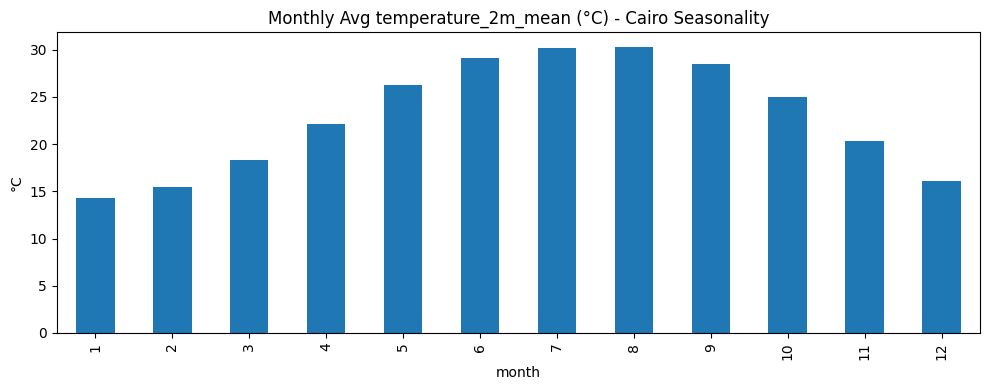

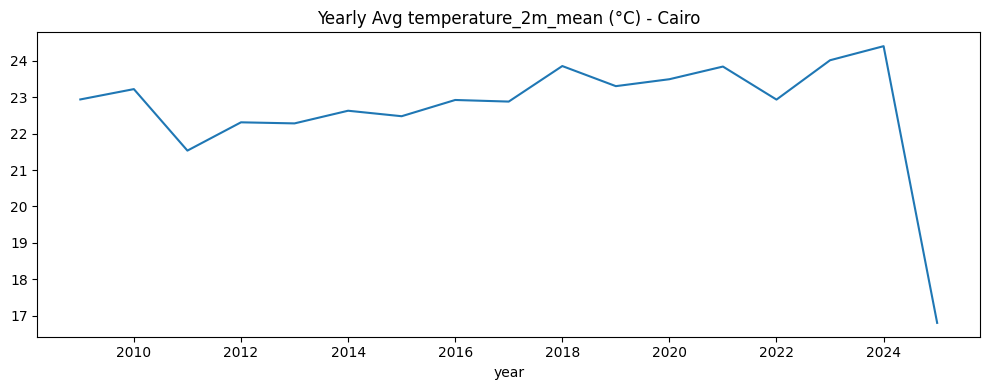

In [10]:
df = df_clean.copy()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
temp_col = next((c for c in num_cols if 'temp' in c.lower()), num_cols[0])
hum_col = next((c for c in num_cols if 'hum' in c.lower()), None)

print(f"Temp: {temp_col}, Hum: {hum_col}")

df['month'] = df.index.month
df['year'] = df.index.year
df['hour'] = df.index.hour

# Monthly
monthly_avg = df.groupby('month')[temp_col].mean()
plt.figure(figsize=(10,4))
monthly_avg.plot(kind='bar')
plt.title(f'Monthly Avg {temp_col} - Cairo Seasonality')
plt.ylabel('°C')
plt.tight_layout()
plt.savefig(FIG_DIR / "cairo_weather_monthly_temp.png", dpi=150)
plt.show()

# Yearly
plt.figure(figsize=(10,4))
df.groupby('year')[temp_col].mean().plot()
plt.title(f'Yearly Avg {temp_col} - Cairo')
plt.tight_layout()
plt.savefig(FIG_DIR / "cairo_weather_yearly_temp.png", dpi=150)
plt.show()

# Hourly if available
if df['hour'].nunique() > 1:
    plt.figure(figsize=(10,4))
    df.groupby('hour')[temp_col].mean().plot()
    plt.title(f'Hourly Pattern {temp_col} - Cairo')
    plt.tight_layout()
    plt.savefig(FIG_DIR / "cairo_weather_hourly_temp.png", dpi=150)
    plt.show()

## 4. Extremes & Distribution
Find hottest/coldest days, missing gaps, outliers.

Max: 37.40 at 2019-05-23 00:00:00+00:00
Min: 8.60 at 2016-01-27 00:00:00+00:00

Top 5 hottest:
                            temperature_2m_mean (°C)
time                                               
2019-05-23 00:00:00+00:00                      37.4
2018-05-22 00:00:00+00:00                      36.9
2020-05-20 00:00:00+00:00                      36.9
2020-05-21 00:00:00+00:00                      36.9
2021-08-05 00:00:00+00:00                      36.4

Top 5 coldest:
                            temperature_2m_mean (°C)
time                                               
2016-01-27 00:00:00+00:00                       8.6
2015-02-19 00:00:00+00:00                       8.7
2016-01-26 00:00:00+00:00                       8.7
2022-01-26 00:00:00+00:00                       8.7
2013-12-13 00:00:00+00:00                       9.0


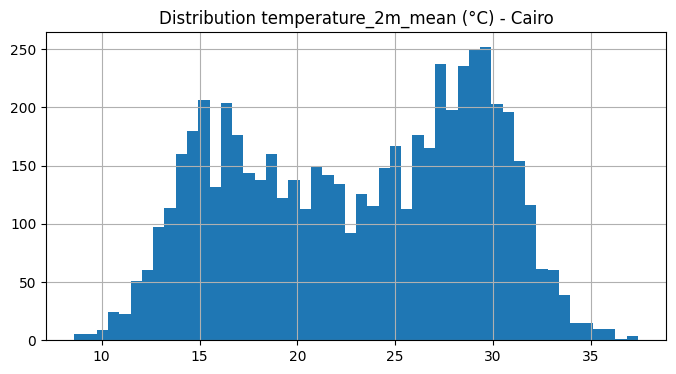

<Figure size 1200x500 with 0 Axes>

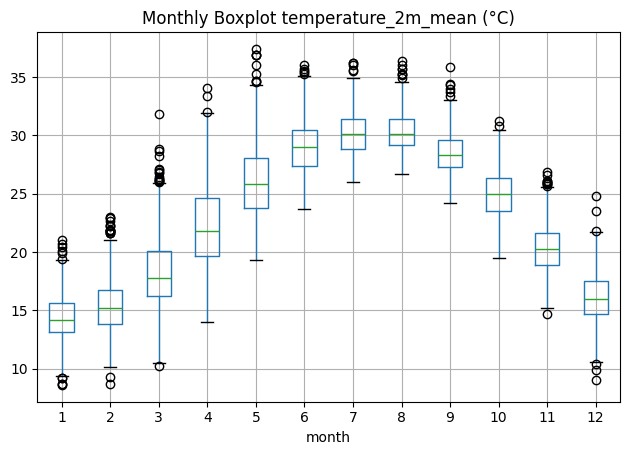


Missing days: 0


In [11]:
print(f"Max: {df_clean[temp_col].max():.2f} at {df_clean[temp_col].idxmax()}")
print(f"Min: {df_clean[temp_col].min():.2f} at {df_clean[temp_col].idxmin()}")
print("\nTop 5 hottest:\n", df_clean.nlargest(5, temp_col)[[temp_col]])
print("\nTop 5 coldest:\n", df_clean.nsmallest(5, temp_col)[[temp_col]])

plt.figure(figsize=(8,4))
df_clean[temp_col].hist(bins=50)
plt.title(f'Distribution {temp_col} - Cairo')
plt.savefig(FIG_DIR / "cairo_weather_temp_hist.png", dpi=150)
plt.show()

plt.figure(figsize=(12,5))
df.boxplot(column=temp_col, by='month')
plt.title(f'Monthly Boxplot {temp_col}')
plt.suptitle('')
plt.tight_layout()
plt.savefig(FIG_DIR / "cairo_weather_temp_boxplot.png", dpi=150)
plt.show()

missing_days = df_clean.resample('D').size()
print(f"\nMissing days: {(missing_days==0).sum()}")

## 5. Save Summary for Dashboard
Do NOT merge with household. Save independent JSON.

In [12]:
import json

summary = {
    "date_range": [str(df_clean.index.min()), str(df_clean.index.max())],
    "total_records": len(df_clean),
    "columns": df_clean.columns.tolist(),
    "missing_after_clean": df_clean.isna().sum().to_dict(),
    "temp_col": temp_col,
    "hum_col": hum_col,
    "temp_stats": {
        "mean": float(df_clean[temp_col].mean()),
        "max": float(df_clean[temp_col].max()),
        "min": float(df_clean[temp_col].min()),
        "max_date": str(df_clean[temp_col].idxmax()),
        "min_date": str(df_clean[temp_col].idxmin()),
    },
    "monthly_avg_temp": df.groupby('month')[temp_col].mean().round(2).to_dict(),
    "note": "Cairo only - not merged with UCI"
}

with open(RES_DIR / "cairo_weather_summary.json", 'w') as f:
    json.dump(summary, f, indent=2)

dashboard_data = {
    "summary": summary,
    "monthly_avg": summary["monthly_avg_temp"],
    "sample_last_30": df_clean.tail(30).reset_index().to_dict(orient='records')
}

with open(DASH_DIR / "cairo_weather.json", 'w') as f:
    json.dump(dashboard_data, f, indent=2, default=str)

print(json.dumps(summary, indent=2))

from google.colab import files
files.download(str(RES_DIR / "cairo_weather_summary.json"))
files.download(str(DASH_DIR / "cairo_weather.json"))

{
  "date_range": [
    "2009-02-01 00:00:00+00:00",
    "2025-02-01 00:00:00+00:00"
  ],
  "total_records": 5845,
  "columns": [
    "temperature_2m_mean (\u00b0C)",
    "rain_sum (mm)",
    "wind_speed_10m_max (km/h)",
    "apparent_temperature_mean (\u00b0C)",
    "temperature_2m_min (\u00b0C)",
    "temperature_2m_max (\u00b0C)",
    "apparent_temperature_max (\u00b0C)",
    "weather_code (wmo code)",
    "wind_direction_10m_dominant (\u00b0)",
    "wind_gusts_10m_max (km/h)",
    "shortwave_radiation_sum (MJ/m\u00b2)",
    "daylight_duration (s)",
    "sunshine_duration (s)",
    "apparent_temperature_min (\u00b0C)",
    "sunrise (iso8601)",
    "sunset (iso8601)",
    "precipitation_hours (h)",
    "precipitation_sum (mm)",
    "et0_fao_evapotranspiration (mm)",
    "snowfall_sum (cm)",
    "cloud_cover_mean (%)",
    "dew_point_2m_mean (\u00b0C)",
    "relative_humidity_2m_mean (%)",
    "visibility_mean (undefined)",
    "visibility_max (undefined)",
    "visibility_min (undefi

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 6. Key Findings

- **Seasonality:** Summer peak Jun-Aug >35°C, winter Jan ~15°C -> AC load story for Cairo.
- **Independent:** UCI household = France, Cairo = Egypt -> keep separate tab in dashboard "Cairo Context".
- **No merge:** scientifically invalid due to different geo/time.

**Upload to GitHub after run:**
- `data/cairo_weather/processed/` (3 csv)
- `reports/figures/` (4 png)
- `reports/results/cairo_weather_summary.json`
- `dashboard/data/cairo_weather.json`